In [37]:
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

Loading Data

In [38]:
sales_train = pd.read_csv("E:/sales_predict/datasets/sales_train.csv")
items = pd.read_csv("E:/sales_predict/datasets/items.csv")
item_categories = pd.read_csv("E:/sales_predict/datasets/item_categories.csv")
shops = pd.read_csv("E:/sales_predict/datasets/shops.csv")
test = pd.read_csv("E:/sales_predict/datasets/test.csv")
sample_submission = pd.read_csv("E:/sales_predict/datasets/sample_submission.csv")

Data research

In [39]:
item_categories.head()

,item_category_name,item_category_id
0,PC - Гарнитуры/Наушники,0
1,Аксессуары - PS2,1
2,Аксессуары - PS3,2
3,Аксессуары - PS4,3
4,Аксессуары - PSP,4


In [40]:
sales_train.head()

,date,date_block_num,shop_id,item_id,item_price,item_cnt_day
0,02.01.2013,0,59,22154,999.00,1.0
1,03.01.2013,0,25,2552,899.00,1.0
2,05.01.2013,0,25,2552,899.00,-1.0
3,06.01.2013,0,25,2554,1709.05,1.0
4,15.01.2013,0,25,2555,1099.00,1.0


In [41]:
items.head()

,item_name,item_id,item_category_id
0,! ВО ВЛАСТИ НАВАЖДЕНИЯ (ПЛАСТ.) D,0,40
1,!ABBYY FineReader 12 Professional Edition Full...,1,76
2,***В ЛУЧАХ СЛАВЫ (UNV) D,2,40
3,***ГОЛУБАЯ ВОЛНА (Univ) D,3,40
4,***КОРОБКА (СТЕКЛО) D,4,40


In [42]:
sample_submission.head()

,ID,item_cnt_month
0,0,0.5
1,1,0.5
2,2,0.5
3,3,0.5
4,4,0.5


In [43]:
shops.head()

,shop_name,shop_id
0,"!Якутск Орджоникидзе, 56 фран",0
1,"!Якутск ТЦ ""Центральный"" фран",1
2,"Адыгея ТЦ ""Мега""",2
3,"Балашиха ТРК ""Октябрь-Киномир""",3
4,"Волжский ТЦ ""Волга Молл""",4


In [44]:
test.head()

,ID,shop_id,item_id
0,0,5,5037
1,1,5,5320
2,2,5,5233
3,3,5,5232
4,4,5,5268


In [45]:
sales_train.loc[sales_train["shop_id"] == 0, "shop_id"] = 57
sales_train.loc[sales_train["shop_id"] == 1, "shop_id"] = 58
sales_train.loc[sales_train["shop_id"] == 10, "shop_id"] = 11
sales_train.loc[sales_train["shop_id"] == 39, "shop_id"] = 40

test.loc[test["shop_id"] == 0, "shop_id"] = 57
test.loc[test["shop_id"] == 1, "shop_id"] = 58
test.loc[test["shop_id"] == 10, "shop_id"] = 11
test.loc[test["shop_id"] == 39, "shop_id"] = 40

Data merging

In [46]:
df = sales_train.merge(items, on='item_id', how='left')

In [47]:
df = df.merge(item_categories, on='item_category_id', how='left')

In [48]:
df = df.merge(shops, on='shop_id', how='left')

In [49]:
df.head()

,date,date_block_num,shop_id,item_id,item_price,item_cnt_day,item_name,item_category_id,item_category_name,shop_name
0,02.01.2013,0,59,22154,999.00,1.0,ЯВЛЕНИЕ 2012 (BD),37,Кино - Blu-Ray,"Ярославль ТЦ ""Альтаир"""
1,03.01.2013,0,25,2552,899.00,1.0,DEEP PURPLE The House Of Blue Light LP,58,Музыка - Винил,"Москва ТРК ""Атриум"""
2,05.01.2013,0,25,2552,899.00,-1.0,DEEP PURPLE The House Of Blue Light LP,58,Музыка - Винил,"Москва ТРК ""Атриум"""
3,06.01.2013,0,25,2554,1709.05,1.0,DEEP PURPLE Who Do You Think We Are LP,58,Музыка - Винил,"Москва ТРК ""Атриум"""
4,15.01.2013,0,25,2555,1099.00,1.0,DEEP PURPLE 30 Very Best Of 2CD (Фирм.),56,Музыка - CD фирменного производства,"Москва ТРК ""Атриум"""


Data conversion

In [50]:
print(df['date'].dtype)
df['date'] = pd.to_datetime(df['date'], format='%d.%m.%Y')
print(df['date'].dtype)
df = df.sort_values('date').reset_index(drop=True)

object
datetime64[ns]


Checking missing data

In [51]:
print(df.isna().sum())
missing_rows = df[df.isna().any(axis=1)]

date                  0
date_block_num        0
shop_id               0
item_id               0
item_price            0
item_cnt_day          0
item_name             0
item_category_id      0
item_category_name    0
shop_name             0
dtype: int64


Duplicates

In [52]:
duplicates = df[df.duplicated()]
print("Дубликаты:", len(duplicates))

Дубликаты: 186


In [53]:
df.drop_duplicates()

,date,date_block_num,shop_id,item_id,item_price,item_cnt_day,item_name,item_category_id,item_category_name,shop_name
0,2013-01-01,0,18,5823,2500.0,1.0,Playstation Store пополнение бумажника: Карта ...,35,Карты оплаты - PSN,"Красноярск ТЦ ""Июнь"""
1,2013-01-01,0,27,5573,849.0,1.0,PS Move Motion Controller Charger (Зарядная ст...,2,Аксессуары - PS3,"Москва ТЦ ""МЕГА Белая Дача II"""
2,2013-01-01,0,7,1006,399.0,1.0,3D Crystal Puzzle Дельфин XL,67,Подарки - Развитие,"Воронеж ТРЦ ""Максимир"""
3,2013-01-01,0,19,17707,899.0,1.0,Праздник спорта (Essentials) (только для PS Mo...,19,Игры - PS3,"Курск ТЦ ""Пушкинский"""
4,2013-01-01,0,14,19548,149.0,1.0,ТАКИЕ РАЗНЫЕ БЛИЗНЕЦЫ (регион),40,Кино - DVD,"Казань ТЦ ""ПаркХаус"" II"
...,...,...,...,...,...,...,...,...,...,...
2935844,2015-10-31,33,41,21386,169.0,1.0,ХОББИТ: ПУСТОШЬ СМАУГА (регион),40,Кино - DVD,"РостовНаДону ТЦ ""Мега"""
2935845,2015-10-31,33,21,988,199.0,1.0,38-Я ПАРАЛЛЕЛЬ (BD),37,Кино - Blu-Ray,"Москва МТРЦ ""Афи Молл"""
2935846,2015-10-31,33,41,21377,169.0,1.0,ХОББИТ: НЕЖДАННОЕ ПУТЕШЕСТВИЕ (регион),40,Кино - DVD,"РостовНаДону ТЦ ""Мега"""
2935847,2015-10-31,33,22,10207,1199.0,1.0,"Ведьмак 3: Дикая охота [PC, Jewel, русская вер...",30,Игры PC - Стандартные издания,Москва Магазин С21


Creating lag features

In [54]:
df['sales_yesterday'] = df.groupby(['shop_id', 'item_id'])['item_cnt_day'].shift(1)

In [55]:
df['sales_last_week'] = df.groupby(['shop_id', 'item_id'])['item_cnt_day'].shift(7)

In [56]:
df['sales_last_month'] = df.groupby(['shop_id', 'item_id'])['item_cnt_day'].shift(30)

In [57]:
print(df['date'].min(), df['date'].max())

2013-01-01 00:00:00 2015-10-31 00:00:00


Data Visualization

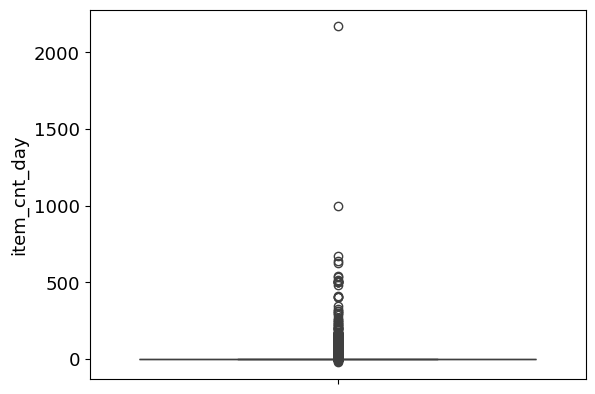

In [58]:
sns.boxplot(y = "item_cnt_day", data = df);

In [59]:
df['returns'] = np.where(df['item_cnt_day'] < 0, -df['item_cnt_day'], 0)
returns_df = df[df['returns'] > 0].copy()

<Axes: xlabel='item_price', ylabel='returns'>

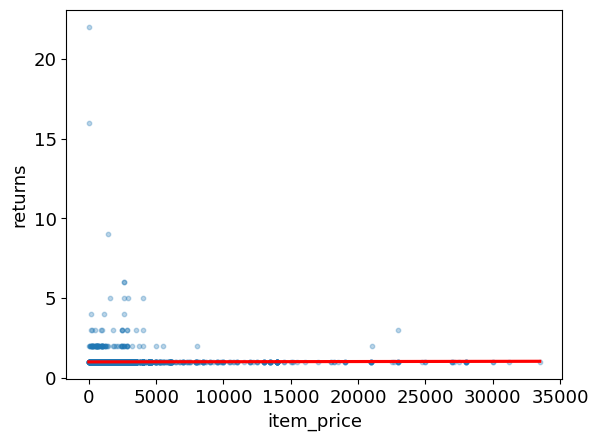

In [60]:
sns.regplot(
    x='item_price', 
    y='returns', 
    data=returns_df,
    scatter_kws={'alpha':0.3, 's':10},
    line_kws={'color':'red'}
)

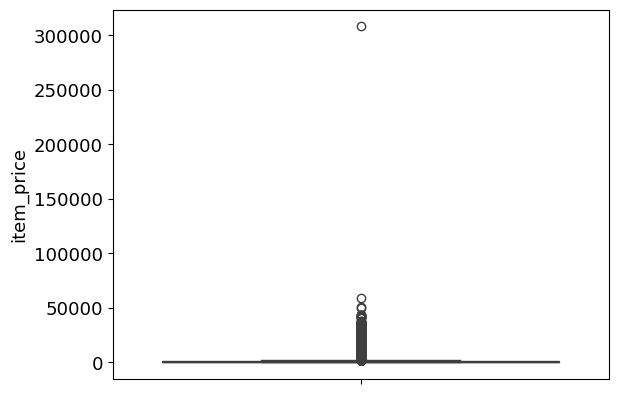

In [61]:
sns.boxplot(y = "item_price", data = df);

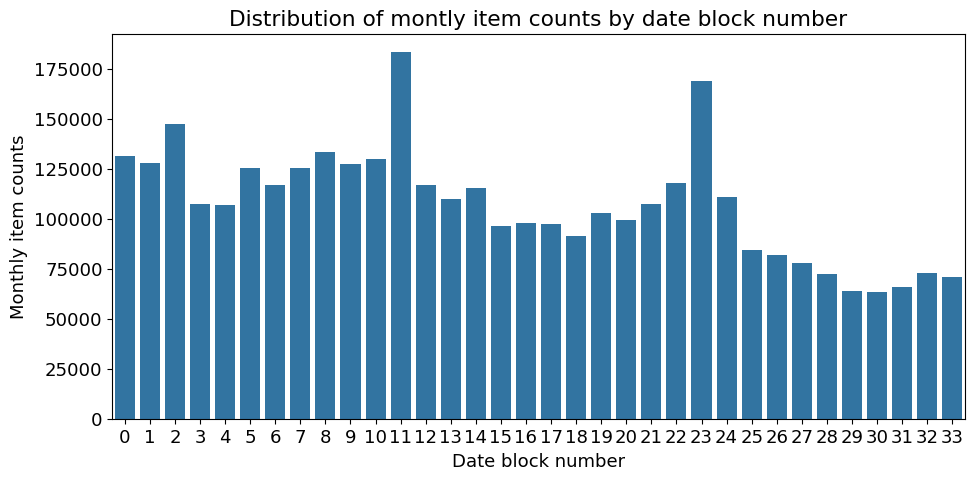

In [62]:
mpl.rc("font", size = 13)
figure, ax = plt.subplots()
figure.set_size_inches(11, 5)

group_month_sum = df.groupby("date_block_num").agg({"item_cnt_day": "sum"}).reset_index()

sns.barplot(x = "date_block_num", y = "item_cnt_day", data = group_month_sum)
ax.set(title = "Distribution of montly item counts by date block number",
       xlabel = "Date block number",
       ylabel = "Monthly item counts");

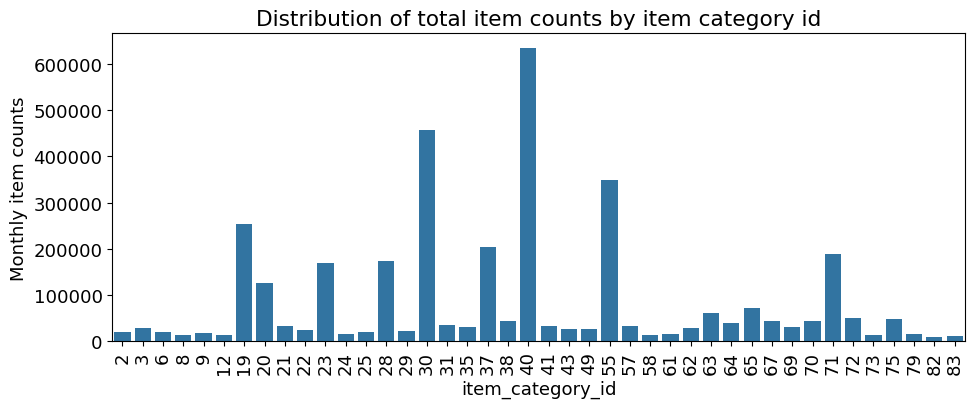

In [63]:
figure, ax = plt.subplots()
figure.set_size_inches(11, 4)

group_cat_sum = df.groupby("item_category_id").agg({"item_cnt_day": "sum"}).reset_index()
group_cat_sum = group_cat_sum[group_cat_sum["item_cnt_day"] > 10000]

sns.barplot(x = "item_category_id", y = "item_cnt_day", data = group_cat_sum)
ax.set(title = "Distribution of total item counts by item category id",
       xlabel = "item_category_id",
       ylabel = "Monthly item counts");
ax.tick_params(axis = "x", labelrotation = 90)

In [64]:
df = df[(df["item_price"] > 0) & (df["item_price"] < 50000)]

In [65]:
for col in ['sales_yesterday', 'sales_last_week', 'sales_last_month']:
    df[col] = df.groupby('item_id')[col].transform(lambda x: x.fillna(0))

In [66]:
df.head()

,date,date_block_num,shop_id,item_id,item_price,item_cnt_day,item_name,item_category_id,item_category_name,shop_name,sales_yesterday,sales_last_week,sales_last_month,returns
0,2013-01-01,0,18,5823,2500.0,1.0,Playstation Store пополнение бумажника: Карта ...,35,Карты оплаты - PSN,"Красноярск ТЦ ""Июнь""",0.0,0.0,0.0,0.0
1,2013-01-01,0,27,5573,849.0,1.0,PS Move Motion Controller Charger (Зарядная ст...,2,Аксессуары - PS3,"Москва ТЦ ""МЕГА Белая Дача II""",0.0,0.0,0.0,0.0
2,2013-01-01,0,7,1006,399.0,1.0,3D Crystal Puzzle Дельфин XL,67,Подарки - Развитие,"Воронеж ТРЦ ""Максимир""",0.0,0.0,0.0,0.0
3,2013-01-01,0,19,17707,899.0,1.0,Праздник спорта (Essentials) (только для PS Mo...,19,Игры - PS3,"Курск ТЦ ""Пушкинский""",0.0,0.0,0.0,0.0
4,2013-01-01,0,14,19548,149.0,1.0,ТАКИЕ РАЗНЫЕ БЛИЗНЕЦЫ (регион),40,Кино - DVD,"Казань ТЦ ""ПаркХаус"" II",0.0,0.0,0.0,0.0


In [67]:
df.isna().sum()

date                  0
date_block_num        0
shop_id               0
item_id               0
item_price            0
item_cnt_day          0
item_name             0
item_category_id      0
item_category_name    0
shop_name             0
sales_yesterday       0
sales_last_week       0
sales_last_month      0
returns               0
dtype: int64